# TopoDL: ResNet50 + Persistent Images for Brain Tumor Classification

This notebook extends the original ResNet50 brain-tumor classifier into a **Topological Deep
Learning (TopoDL)** model:

1. The raw RGB brain image is encoded by a pretrained ResNet50.
2. Cubical persistent homology extracts $H_0$ and $H_1$ intervals from a grayscale image.
3. The intervals are converted and cached as PI-$H_0$ and PI-$H_1$ persistence images.
4. PI-$H_0$ and PI-$H_1$ are encoded by two independent CNN branches.
5. The three embedding vectors are concatenated, linearly fused, and classified.

The original polygon masks are retained for visualization and Grad-CAM localization analysis.


## 1. Optional Setup


In [1]:
# Run once in a fresh Colab or notebook environment.
!pip install -q datasets transformers accelerate pillow matplotlib tqdm scikit-learn gudhi


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.3/4.3 MB 28.5 MB/s eta 0:00:00


## 2. Import Libraries


In [2]:
import random
from collections import defaultdict
from pathlib import Path

import gudhi as gd
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from datasets import load_dataset
from PIL import Image, ImageDraw
from sklearn.metrics import classification_report, confusion_matrix
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from torchvision.models import ResNet50_Weights, resnet50
from tqdm.auto import tqdm


## 3. Configuration and Reproducibility


In [3]:
SEED = 42
DATASET_NAME = "dwb2023/brain-tumor-image-dataset-semantic-segmentation"

# ResNet50 consumes 224 x 224 RGB images. Topology is extracted from a smaller
# grayscale image because cubical persistence does not require ImageNet resolution.
IMG_SIZE = 224
TOPOLOGY_INPUT_SIZE = 64
PI_SIZE = 32
PI_SIGMA = 0.055
PI_MAX_PERSISTENCE = 1.0

BATCH_SIZE = 16
EPOCHS = 20
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-4
BRANCH_EMBEDDING_DIM = 128
RESNET_EMBEDDING_DIM = 256

# Keep these small for a classroom demo. Set to None to use full splits.
TRAIN_LIMIT = 600
VAL_LIMIT = 160
TEST_LIMIT = 80

PI_CACHE_DIR = Path("./brain_tumor_pi_cache")
CHECKPOINT_DIR = Path("./checkpoints_brain_tumor_topodl")
CHECKPOINT_PATH = CHECKPOINT_DIR / "best_topodl_resnet50_brain_tumor.pt"
PI_CACHE_DIR.mkdir(parents=True, exist_ok=True)


def seed_everything(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


seed_everything()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


Device: cuda


## 4. Load the HuggingFace Brain Tumor Dataset


In [4]:
raw_datasets = load_dataset(DATASET_NAME)
print(raw_datasets)
print("Features:", raw_datasets["train"].features)
print("Train example keys:", raw_datasets["train"][0].keys())


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/6.22k [00:00<?, ?B/s]

data/train-00000-of-00001-1d7ef230dfbdad(…):   0%|          | 0.00/113M [00:00<?, ?B/s]

data/test-00000-of-00001-0031debf8df4462(…):   0%|          | 0.00/16.3M [00:00<?, ?B/s]

data/valid-00000-of-00001-bce5cef16a5cce(…):   0%|          | 0.00/32.2M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/1502 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/215 [00:00<?, ? examples/s]

Generating valid split:   0%|          | 0/429 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['file_name', 'image', 'id', 'category_id', 'bbox', 'segmentation', 'area', 'iscrowd', 'height', 'width', 'date_captured', 'license'],
        num_rows: 1502
    })
    test: Dataset({
        features: ['file_name', 'image', 'id', 'category_id', 'bbox', 'segmentation', 'area', 'iscrowd', 'height', 'width', 'date_captured', 'license'],
        num_rows: 215
    })
    valid: Dataset({
        features: ['file_name', 'image', 'id', 'category_id', 'bbox', 'segmentation', 'area', 'iscrowd', 'height', 'width', 'date_captured', 'license'],
        num_rows: 429
    })
})
Features: {'file_name': Value('string'), 'image': Image(mode=None, decode=True), 'id': Value('int64'), 'category_id': ClassLabel(names=['Tumor', '0', '1']), 'bbox': List(Value('float32'), length=4), 'segmentation': List(List(Value('float32'))), 'area': Value('float32'), 'iscrowd': Value('int64'), 'height': Value('int64'), 'width': Value('int64'), 'date_captured': Value('s

## 5. Select Splits and Build Label Mapping


In [5]:
def select_limit(dataset_split, limit):
    if limit is None:
        return dataset_split
    return dataset_split.select(range(min(limit, len(dataset_split))))


train_split = select_limit(raw_datasets["train"], TRAIN_LIMIT)
val_split = select_limit(raw_datasets["valid"], VAL_LIMIT)
test_split = select_limit(raw_datasets["test"], TEST_LIMIT)

observed_raw_labels = sorted({
    int(example["category_id"])
    for split in [train_split, val_split, test_split]
    for example in split
})
LABEL_TO_IDX = {raw_label: idx for idx, raw_label in enumerate(observed_raw_labels)}
IDX_TO_LABEL = {idx: f"category_id={raw_label}" for raw_label, idx in LABEL_TO_IDX.items()}
NUM_CLASSES = len(LABEL_TO_IDX)

print("LABEL_TO_IDX:", LABEL_TO_IDX)
print("Split sizes:", len(train_split), len(val_split), len(test_split))


LABEL_TO_IDX: {1: 0, 2: 1}
Split sizes: 600 160 80


## 6. Polygon Masks and Image Utilities


In [6]:
def polygon_to_mask(segmentation, width, height, output_size=IMG_SIZE):
    # Convert COCO-style polygon segmentation into a binary tensor [1, H, W].
    mask = Image.new("L", (int(width), int(height)), 0)
    drawer = ImageDraw.Draw(mask)
    if segmentation is not None:
        for polygon in segmentation:
            if polygon is None or len(polygon) < 6:
                continue
            points = [
                (float(polygon[i]), float(polygon[i + 1]))
                for i in range(0, len(polygon), 2)
            ]
            drawer.polygon(points, outline=1, fill=1)
    mask = mask.resize((output_size, output_size), resample=Image.Resampling.NEAREST)
    return torch.from_numpy((np.asarray(mask) > 0).astype(np.float32)).unsqueeze(0)


def denorm_imagenet(x_chw):
    mean = np.array([0.485, 0.456, 0.406], dtype=np.float32)
    std = np.array([0.229, 0.224, 0.225], dtype=np.float32)
    x = x_chw.transpose(1, 2, 0) * std + mean
    return np.clip(x, 0.0, 1.0)


## 7. Extract and Cache PI-$H_0$ / PI-$H_1$

Each RGB image is converted to grayscale and resized to `TOPOLOGY_INPUT_SIZE`. The cubical
filtration uses `1 - intensity`, so brighter anatomical structures enter before darker regions.
Finite persistence intervals are converted from `(birth, death)` to `(birth, persistence)` and
rasterized using persistence-weighted Gaussian kernels.


In [7]:
def extract_cubical_intervals(gray_image, dimension):
    '''Extract finite persistence intervals from one grayscale image.'''
    filtration = 1.0 - np.asarray(gray_image, dtype=np.float64)
    complex_ = gd.CubicalComplex(top_dimensional_cells=filtration)
    complex_.compute_persistence(homology_coeff_field=2, min_persistence=0.0)
    intervals = complex_.persistence_intervals_in_dimension(dimension)
    if len(intervals) == 0:
        return np.empty((0, 2), dtype=np.float32)
    return intervals[np.isfinite(intervals[:, 1])].astype(np.float32)


def intervals_to_pi(intervals, size=PI_SIZE, sigma=PI_SIGMA):
    '''Convert intervals to a normalized persistence image.'''
    if len(intervals) == 0:
        return np.zeros((size, size), dtype=np.float32)
    births = np.clip(intervals[:, 0], 0.0, 1.0)
    persistence = np.clip(intervals[:, 1] - intervals[:, 0], 0.0, PI_MAX_PERSISTENCE)
    axis = np.linspace(0.0, 1.0, size, dtype=np.float32)
    xx, yy = np.meshgrid(axis, axis)
    surface = np.zeros((size, size), dtype=np.float32)
    for birth, life in zip(births, persistence):
        surface += life * np.exp(-((xx - birth) ** 2 + (yy - life) ** 2) / (2 * sigma**2))
    if surface.max() > 0:
        surface /= surface.max()
    return surface.astype(np.float32)


def image_to_h0_h1_pi(pil_image):
    '''Extract H0 and H1 persistence images from a PIL image.'''
    gray = pil_image.convert("L").resize(
        (TOPOLOGY_INPUT_SIZE, TOPOLOGY_INPUT_SIZE), Image.Resampling.BILINEAR
    )
    gray = np.asarray(gray, dtype=np.float32) / 255.0
    return (
        intervals_to_pi(extract_cubical_intervals(gray, 0)),
        intervals_to_pi(extract_cubical_intervals(gray, 1)),
    )


def build_or_load_pi_cache(hf_split, split_name):
    '''Load a split cache, or extract and save all H0/H1 persistence images.'''
    cache_path = PI_CACHE_DIR / f"{split_name}_n{len(hf_split)}_pi{PI_SIZE}.npz"
    if cache_path.exists():
        cached = np.load(cache_path)
        if len(cached["labels"]) == len(hf_split):
            print("Loaded topology cache:", cache_path)
            return cached["h0"], cached["h1"]

    h0 = np.zeros((len(hf_split), PI_SIZE, PI_SIZE), dtype=np.float32)
    h1 = np.zeros_like(h0)
    labels = np.zeros(len(hf_split), dtype=np.int64)
    for index in tqdm(range(len(hf_split)), desc=f"Extracting topology: {split_name}"):
        example = hf_split[index]
        h0[index], h1[index] = image_to_h0_h1_pi(example["image"])
        labels[index] = LABEL_TO_IDX[int(example["category_id"])]
    np.savez_compressed(cache_path, h0=h0, h1=h1, labels=labels)
    print("Saved topology cache:", cache_path.resolve())
    return h0, h1


train_h0, train_h1 = build_or_load_pi_cache(train_split, "train")
val_h0, val_h1 = build_or_load_pi_cache(val_split, "valid")
test_h0, test_h1 = build_or_load_pi_cache(test_split, "test")
print("PI shapes:", train_h0.shape, train_h1.shape)


Extracting topology: train:   0%|          | 0/600 [00:00<?, ?it/s]

Saved topology cache: /content/brain_tumor_pi_cache/train_n600_pi32.npz


Extracting topology: valid:   0%|          | 0/160 [00:00<?, ?it/s]

Saved topology cache: /content/brain_tumor_pi_cache/valid_n160_pi32.npz


Extracting topology: test:   0%|          | 0/80 [00:00<?, ?it/s]

Saved topology cache: /content/brain_tumor_pi_cache/test_n80_pi32.npz
PI shapes: (600, 32, 32) (600, 32, 32)


## 8. Visualize Raw Image, Tumor Mask, PI-H0, and PI-H1


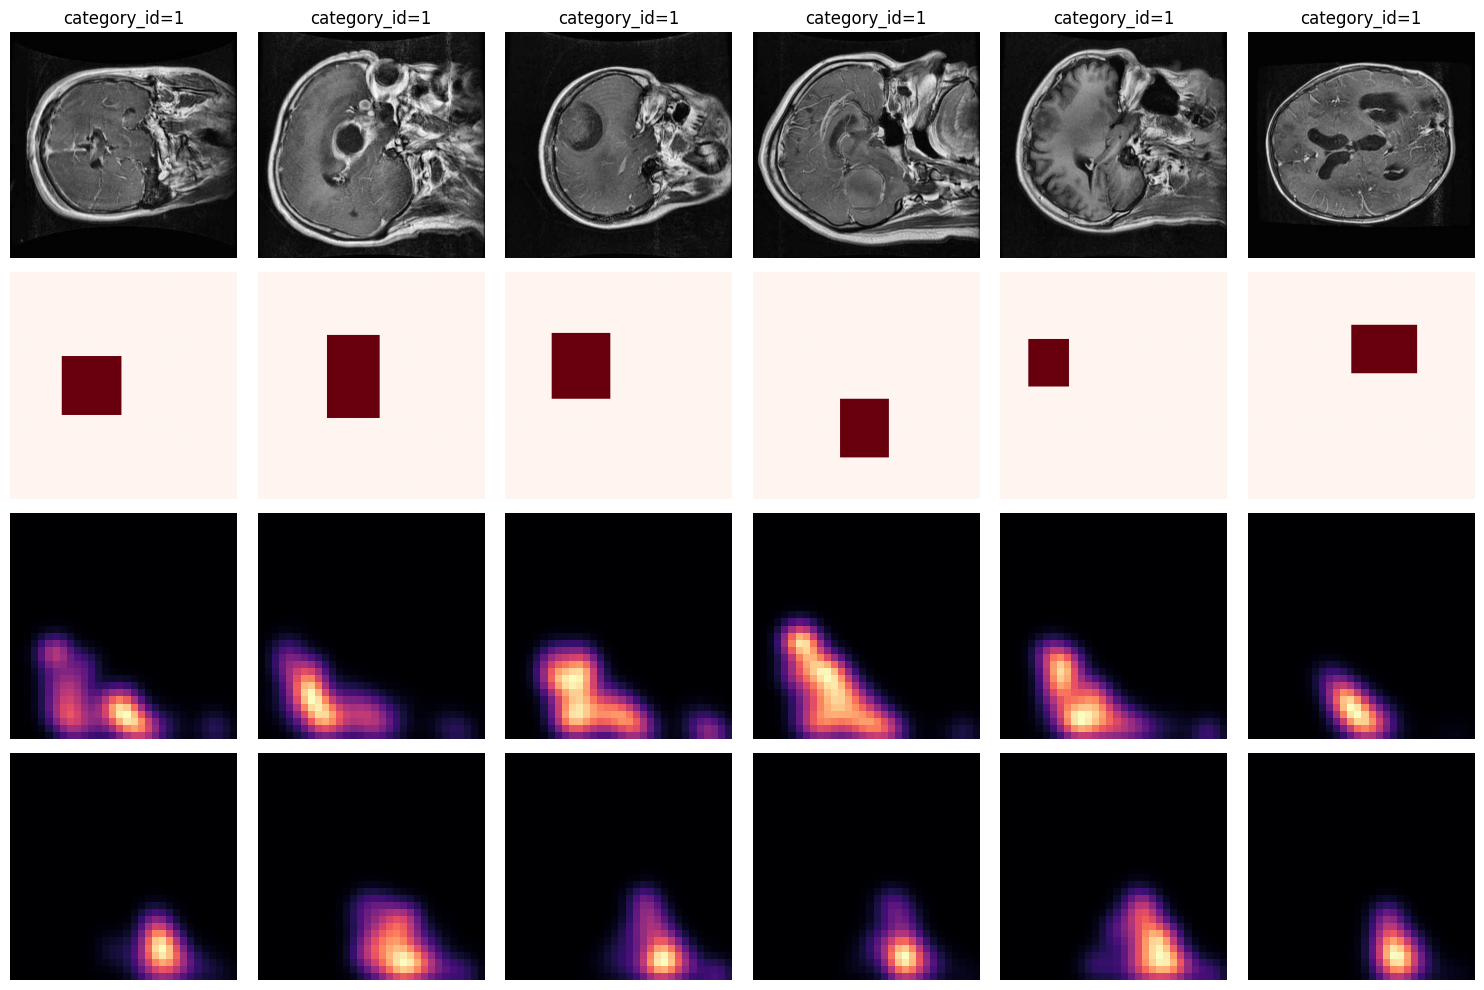

In [8]:
fig, axes = plt.subplots(4, 6, figsize=(15, 10))
for index in range(6):
    example = train_split[index]
    image = example["image"].convert("RGB")
    mask = polygon_to_mask(
        example.get("segmentation"), example.get("width", image.width),
        example.get("height", image.height)
    ).squeeze(0)

    axes[0, index].imshow(image)
    axes[0, index].set_title(IDX_TO_LABEL[LABEL_TO_IDX[int(example["category_id"])]])
    axes[1, index].imshow(mask, cmap="Reds")
    axes[2, index].imshow(train_h0[index], cmap="magma", origin="lower")
    axes[3, index].imshow(train_h1[index], cmap="magma", origin="lower")
    for row in range(4):
        axes[row, index].axis("off")

for row, name in enumerate(["Raw", "GT mask", "PI H0", "PI H1"]):
    axes[row, 0].set_ylabel(name, fontsize=12)
plt.tight_layout()
plt.show()


## 9. Three-Input Dataset and DataLoaders


In [9]:
train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225)),
])
eval_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225)),
])


class TopoDLBrainTumorDataset(Dataset):
    '''Return raw image, cached H0/H1 PIs, GT mask, label, and metadata.'''
    def __init__(self, hf_split, h0, h1, image_transform):
        self.hf_split, self.h0, self.h1 = hf_split, h0, h1
        self.image_transform = image_transform

    def __len__(self):
        return len(self.hf_split)

    def __getitem__(self, index):
        example = self.hf_split[index]
        image = example["image"].convert("RGB")
        image_tensor = self.image_transform(image)
        mask = polygon_to_mask(
            example.get("segmentation"), example.get("width", image.width),
            example.get("height", image.height)
        )
        h0 = torch.from_numpy(self.h0[index]).unsqueeze(0)
        h1 = torch.from_numpy(self.h1[index]).unsqueeze(0)
        label = LABEL_TO_IDX[int(example["category_id"])]
        meta = {"file_name": example.get("file_name", f"sample_{index}")}
        return image_tensor, h0, h1, mask, torch.tensor(label), meta


train_ds = TopoDLBrainTumorDataset(train_split, train_h0, train_h1, train_tf)
val_ds = TopoDLBrainTumorDataset(val_split, val_h0, val_h1, eval_tf)
test_ds = TopoDLBrainTumorDataset(test_split, test_h0, test_h1, eval_tf)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

image, h0, h1, mask, label, meta = next(iter(train_loader))
print("Batch shapes:", image.shape, h0.shape, h1.shape, mask.shape, label.shape)


Batch shapes: torch.Size([16, 3, 224, 224]) torch.Size([16, 1, 32, 32]) torch.Size([16, 1, 32, 32]) torch.Size([16, 1, 224, 224]) torch.Size([16])


## 10. TopoDL Model: ResNet50 Raw Branch + Two Topology CNN Branches


In [10]:
class TopologyCNN(nn.Module):
    '''Encode one persistence image into a topology embedding vector.'''
    def __init__(self, embedding_dim=BRANCH_EMBEDDING_DIM):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1), nn.BatchNorm2d(16), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1)), nn.Flatten(),
            nn.Linear(64, embedding_dim), nn.ReLU(),
        )

    def forward(self, x):
        return self.encoder(x)


class TopoDLResNet50(nn.Module):
    '''Fuse ResNet50 image features with independent H0 and H1 CNN embeddings.'''
    def __init__(self, num_classes):
        super().__init__()
        self.raw_resnet = resnet50(weights=ResNet50_Weights.DEFAULT)
        resnet_features = self.raw_resnet.fc.in_features
        self.raw_resnet.fc = nn.Identity()
        self.raw_projection = nn.Sequential(
            nn.Linear(resnet_features, RESNET_EMBEDDING_DIM), nn.ReLU(), nn.Dropout(0.2)
        )
        self.h0_cnn = TopologyCNN()
        self.h1_cnn = TopologyCNN()
        fusion_dim = RESNET_EMBEDDING_DIM + 2 * BRANCH_EMBEDDING_DIM
        self.fusion = nn.Sequential(
            nn.Linear(fusion_dim, 256), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(256, num_classes),
        )

    def forward(self, image, h0, h1):
        raw_vector = self.raw_projection(self.raw_resnet(image))
        h0_vector = self.h0_cnn(h0)
        h1_vector = self.h1_cnn(h1)
        return self.fusion(torch.cat([raw_vector, h0_vector, h1_vector], dim=1))


model = TopoDLResNet50(NUM_CLASSES).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
print(model)
print("Trainable parameters:", sum(p.numel() for p in model.parameters() if p.requires_grad))


Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 184MB/s]


TopoDLResNet50(
  (raw_resnet): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Sequential(


## 11. Train and Evaluate the Fusion Classifier


In [11]:
def move_batch(batch):
    image, h0, h1, mask, label, meta = batch
    return image.to(device), h0.to(device), h1.to(device), mask.to(device), label.to(device), meta


@torch.no_grad()
def evaluate(loader, return_predictions=False):
    model.eval()
    total = correct = 0
    loss_sum = 0.0
    predictions, labels = [], []
    for batch in loader:
        image, h0, h1, mask, y, meta = move_batch(batch)
        logits = model(image, h0, h1)
        loss_sum += criterion(logits, y).item() * image.size(0)
        pred = logits.argmax(1)
        correct += (pred == y).sum().item()
        total += image.size(0)
        predictions.extend(pred.cpu().numpy())
        labels.extend(y.cpu().numpy())
    result = (loss_sum / total, correct / total)
    return result + (np.asarray(predictions), np.asarray(labels)) if return_predictions else result


def train_one_epoch():
    model.train()
    total = correct = 0
    loss_sum = 0.0
    for batch in tqdm(train_loader, leave=False):
        image, h0, h1, mask, y, meta = move_batch(batch)
        optimizer.zero_grad(set_to_none=True)
        logits = model(image, h0, h1)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()
        loss_sum += loss.item() * image.size(0)
        correct += (logits.argmax(1) == y).sum().item()
        total += image.size(0)
    return loss_sum / total, correct / total


history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
best_val_acc, best_state = -1.0, None
for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = train_one_epoch()
    val_loss, val_acc = evaluate(val_loader)
    for key, value in [
        ("train_loss", train_loss), ("train_acc", train_acc),
        ("val_loss", val_loss), ("val_acc", val_acc)
    ]:
        history[key].append(value)
    print(f"Epoch {epoch:02d} | train loss={train_loss:.4f}, acc={train_acc:.4f} | "
          f"val loss={val_loss:.4f}, acc={val_acc:.4f}")
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

if best_state is not None:
    model.load_state_dict(best_state)
    CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
    torch.save(model.state_dict(), CHECKPOINT_PATH)
    print("Saved checkpoint:", CHECKPOINT_PATH)


  0%|          | 0/38 [00:00<?, ?it/s]

Epoch 01 | train loss=0.5278, acc=0.7967 | val loss=0.1696, acc=0.9125


  0%|          | 0/38 [00:00<?, ?it/s]

Epoch 02 | train loss=0.1118, acc=0.9683 | val loss=0.1563, acc=0.9625


  0%|          | 0/38 [00:00<?, ?it/s]

...

Epoch 18 | train loss=0.0009, acc=1.0000 | val loss=0.0442, acc=0.9938


  0%|          | 0/38 [00:00<?, ?it/s]

Epoch 19 | train loss=0.0007, acc=1.0000 | val loss=0.0631, acc=0.9875


  0%|          | 0/38 [00:00<?, ?it/s]

Epoch 20 | train loss=0.0080, acc=0.9950 | val loss=0.0517, acc=0.9875
Saved checkpoint: checkpoints_brain_tumor_topodl/best_topodl_resnet50_brain_tumor.pt


## 12. Training Curves and Final Classification Results


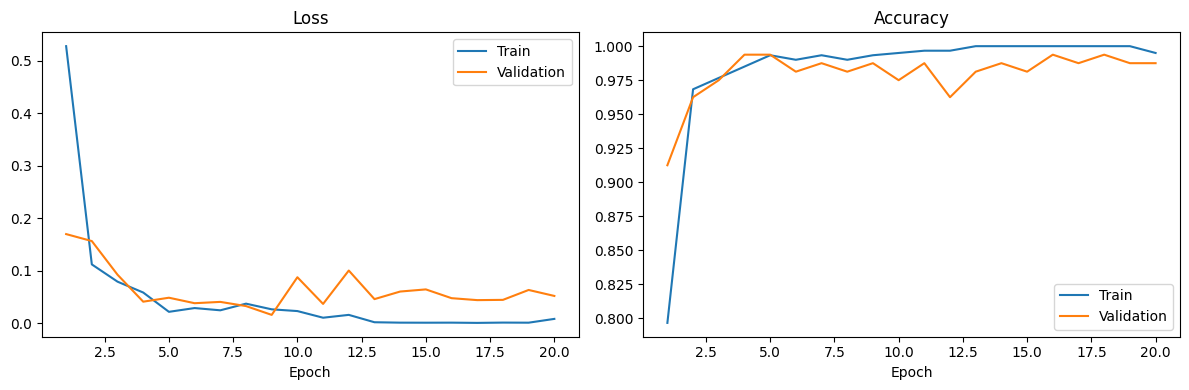

Test loss=0.0909, accuracy=0.9750
               precision    recall  f1-score   support

category_id=1     1.0000    0.9583    0.9787        48
category_id=2     0.9412    1.0000    0.9697        32

     accuracy                         0.9750        80
    macro avg     0.9706    0.9792    0.9742        80
 weighted avg     0.9765    0.9750    0.9751        80



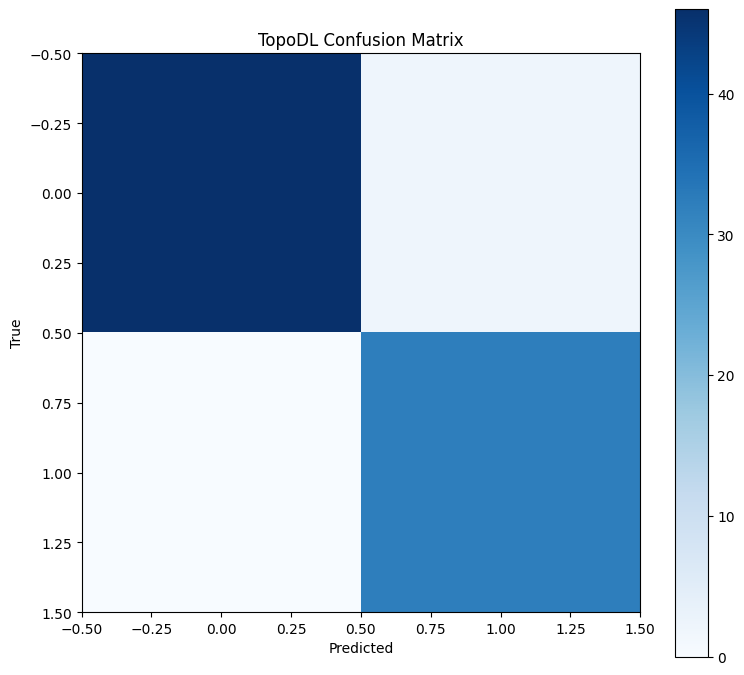

In [12]:
epochs = range(1, len(history["train_loss"]) + 1)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(epochs, history["train_loss"], label="Train")
axes[0].plot(epochs, history["val_loss"], label="Validation")
axes[0].set(title="Loss", xlabel="Epoch"); axes[0].legend()
axes[1].plot(epochs, history["train_acc"], label="Train")
axes[1].plot(epochs, history["val_acc"], label="Validation")
axes[1].set(title="Accuracy", xlabel="Epoch"); axes[1].legend()
plt.tight_layout(); plt.show()

test_loss, test_acc, test_pred, test_labels = evaluate(test_loader, return_predictions=True)
print(f"Test loss={test_loss:.4f}, accuracy={test_acc:.4f}")
print(classification_report(
    test_labels, test_pred,
    target_names=[IDX_TO_LABEL[i] for i in range(NUM_CLASSES)],
    digits=4,
))

cm = confusion_matrix(test_labels, test_pred)
plt.figure(figsize=(8, 7)); plt.imshow(cm, cmap="Blues"); plt.colorbar()
plt.title("TopoDL Confusion Matrix"); plt.xlabel("Predicted"); plt.ylabel("True")
plt.tight_layout(); plt.show()


## 13. Visualize Predictions with PI-H0 and PI-H1


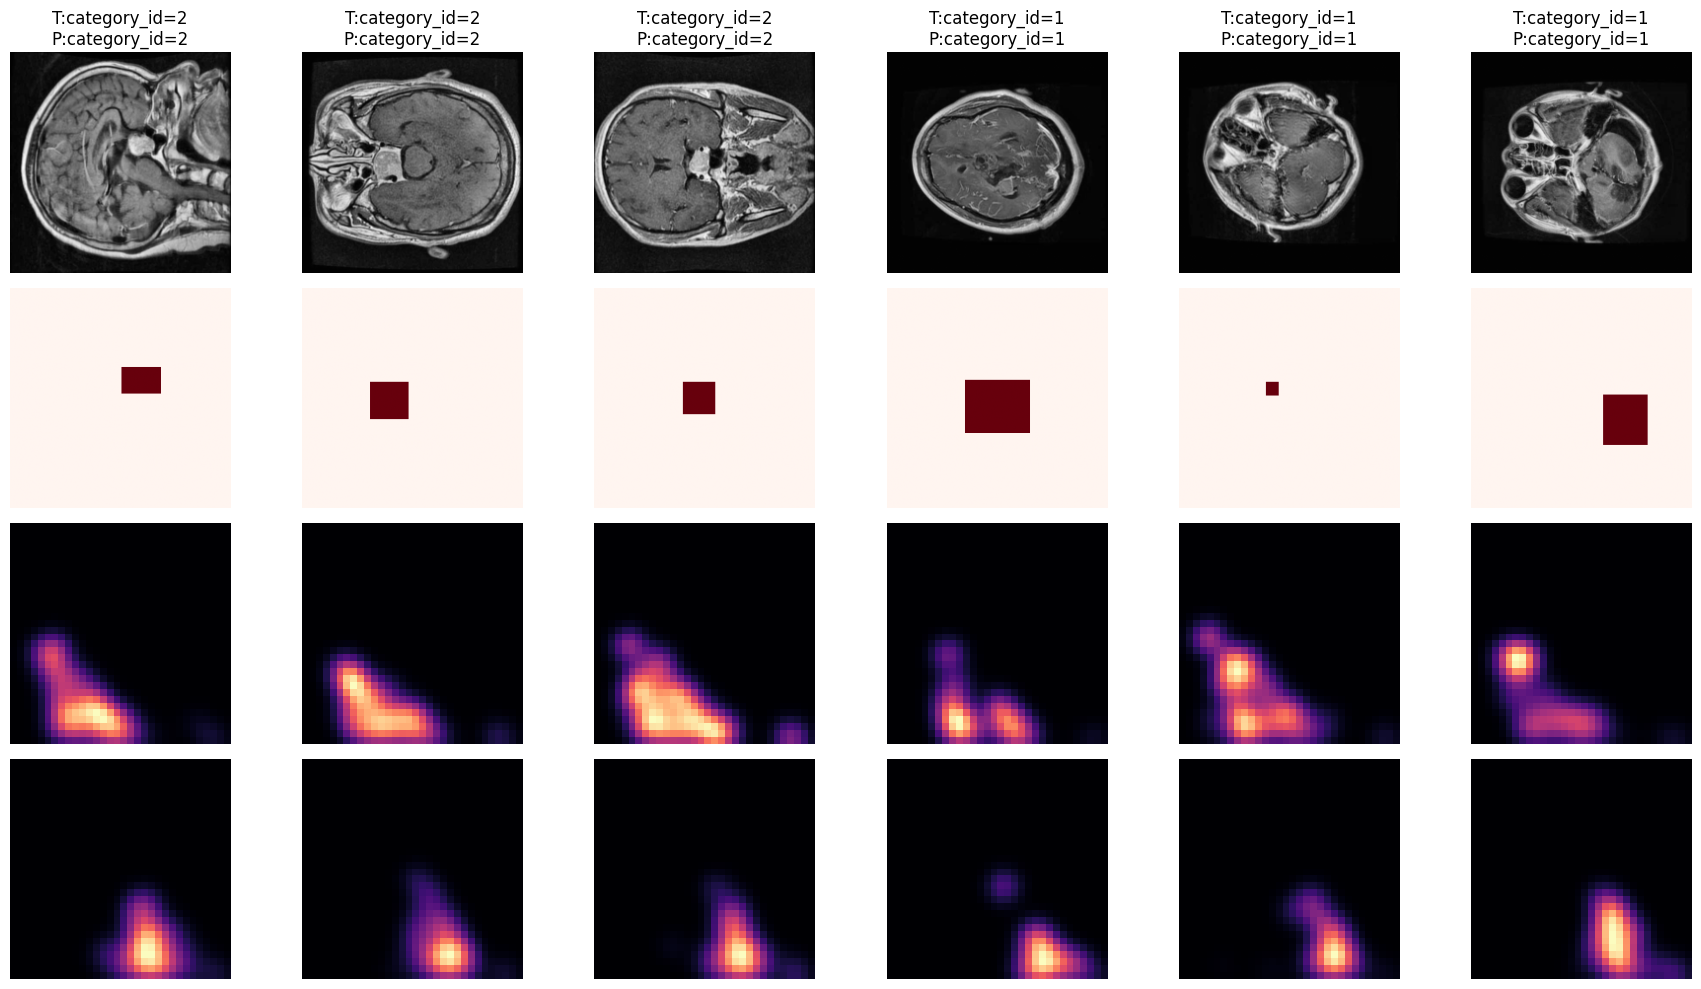

In [13]:
@torch.no_grad()
def show_predictions(loader, n=6):
    model.eval()
    image, h0, h1, mask, y, meta = next(iter(loader))
    logits = model(image.to(device), h0.to(device), h1.to(device))
    probs = torch.softmax(logits, 1).cpu()
    pred = probs.argmax(1)
    fig, axes = plt.subplots(4, n, figsize=(3 * n, 10))
    for i in range(n):
        axes[0, i].imshow(denorm_imagenet(image[i].numpy()))
        axes[0, i].set_title(f"T:{IDX_TO_LABEL[int(y[i])]}\nP:{IDX_TO_LABEL[int(pred[i])]}")
        axes[1, i].imshow(mask[i, 0], cmap="Reds")
        axes[2, i].imshow(h0[i, 0], cmap="magma", origin="lower")
        axes[3, i].imshow(h1[i, 0], cmap="magma", origin="lower")
        for row in range(4): axes[row, i].axis("off")
    for row, name in enumerate(["Raw", "GT mask", "PI H0", "PI H1"]):
        axes[row, 0].set_ylabel(name)
    plt.tight_layout(); plt.show()


show_predictions(test_loader, n=6)


## 14. Grad-CAM for the Raw ResNet50 Branch

Grad-CAM is attached only to `model.raw_resnet.layer4`. The resulting heatmap explains the visual
ResNet50 contribution; PI branches contribute separate topological evidence during fusion.


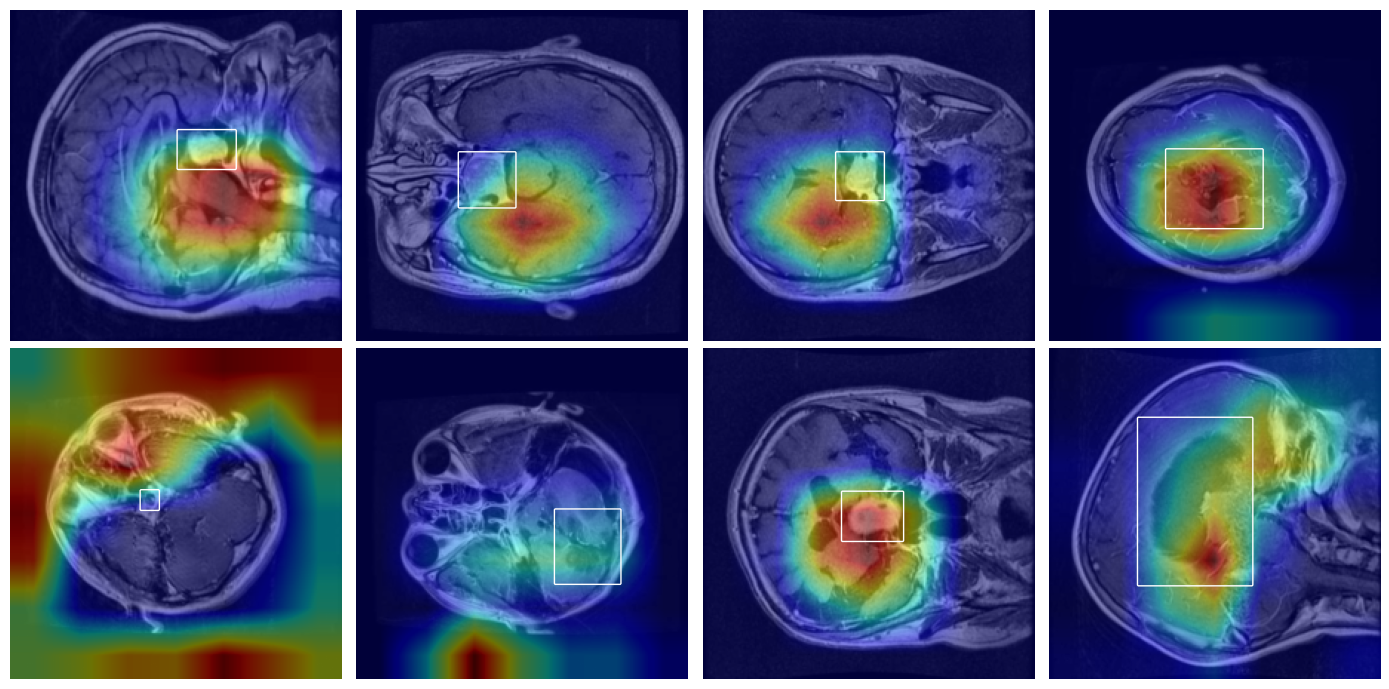

In [14]:
class RawBranchGradCAM:
    def __init__(self, topodl_model, target_layer):
        self.model = topodl_model
        self.activations = self.gradients = None
        self.h1 = target_layer.register_forward_hook(
            lambda module, inputs, output: setattr(self, "activations", output)
        )
        self.h2 = target_layer.register_full_backward_hook(
            lambda module, grad_input, grad_output: setattr(self, "gradients", grad_output[0])
        )

    def generate(self, image, h0, h1, class_idx=None):
        self.model.eval()
        logits = self.model(image, h0, h1)
        if class_idx is None:
            class_idx = logits.argmax(1)
        self.model.zero_grad(set_to_none=True)
        logits.gather(1, class_idx[:, None]).sum().backward()
        weights = self.gradients.mean((2, 3), keepdim=True)
        cam = F.relu((weights * self.activations).sum(1))
        cam = (cam - cam.amin((1, 2), keepdim=True)) / (
            cam.amax((1, 2), keepdim=True) - cam.amin((1, 2), keepdim=True) + 1e-8
        )
        cam = F.interpolate(cam[:, None], image.shape[-2:], mode="bilinear", align_corners=False)
        return cam[:, 0].detach(), logits.detach()

    def close(self):
        self.h1.remove(); self.h2.remove()


cam_engine = RawBranchGradCAM(model, model.raw_resnet.layer4[-1].conv3)
image, h0, h1, mask, y, meta = next(iter(test_loader))
image_device = image.to(device).requires_grad_(True)
cam, logits = cam_engine.generate(image_device, h0.to(device), h1.to(device))

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for i, ax in enumerate(axes.flat):
    raw = denorm_imagenet(image[i].numpy())
    ax.imshow(raw); ax.imshow(cam[i].cpu(), cmap="jet", alpha=0.45)
    ax.contour(mask[i, 0], levels=[0.5], colors="white", linewidths=1)
    ax.axis("off")
plt.tight_layout(); plt.show()
cam_engine.close()


## Discussion Questions

1. Which brain-tumor classes benefit most from PI-$H_0$ and PI-$H_1$ features?
2. Compare this fusion model against the original ResNet50-only baseline.
3. How do `TOPOLOGY_INPUT_SIZE`, `PI_SIZE`, and `PI_SIGMA` affect cost and accuracy?
4. Why should PI features be cached before neural-network training?
5. What does raw-branch Grad-CAM explain, and what topology-branch behavior does it not explain?
